In [88]:
import numpy as np
from landlab import RasterModelGrid
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
)
import matplotlib.pyplot as plt
np.random.seed(seed=5000)

In [89]:
# Code block 0.1

# Import some non-landlab libraries
import numpy as np
import matplotlib as mpl

# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler
from landlab.plot.graph import plot_graph
from tqdm import trange

In [90]:
mg = RasterModelGrid((5, 5), xy_spacing=10.0)
_ = mg.add_zeros("topographic__elevation", at="node")
mg.at_node["topographic__elevation"] += (
    mg.node_y / 10.0 + mg.node_x / 10.0 + np.random.rand(len(mg.node_y)) / 10.0
)
mg.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=True,
    left_is_closed=True,
    right_is_closed=True,
    top_is_closed=True,
)
mg.set_watershed_boundary_condition_outlet_id(
    0, mg.at_node["topographic__elevation"], -9999.0
)
fsc_dt = 100.0
space_dt = 100.0

fr = FlowAccumulator(mg, flow_director="D8")
df = DepressionFinderAndRouter(mg)
fsc = FastscapeEroder(mg, K_sp=0.001, m_sp=0.5, n_sp=1)

for _ in range(100):
    fr.run_one_step()
    df.map_depressions()
    fsc.run_one_step(dt=fsc_dt)
    mg.at_node["topographic__elevation"][0] -= 0.001  # Uplift

_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 0.5
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

In [91]:
mg.at_node["soil__depth"].copy()

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [92]:
mg.at_node["topographic__elevation"].copy()

array([0.42290479, 1.53606698, 2.5727653 , 3.51126678, 4.56077707,
       1.58157495, 0.42861884, 0.43568543, 0.44640869, 5.50969486,
       2.54008677, 0.43569907, 0.43570702, 0.44757547, 6.52641123,
       3.55874171, 0.44671328, 0.44758142, 0.46543073, 7.55334077,
       4.55922478, 5.5409473 , 6.57035008, 7.5038935 , 8.51034357])

In [93]:
Grid_topo = []

In [94]:
ha = Space(
    mg,
    K_sed=0.00001,
    K_br=0.00000000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

for _ in range(2000):  # Space component loop
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    elevation_grid = mg.at_node["soil__depth"].copy()
    Grid_topo.append(elevation_grid)
    mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt

In [95]:
mg.at_node["soil__depth"]

array([0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
       0.5       , 0.49519113, 0.4924996 , 0.49111513, 0.5       ,
       0.5       , 0.49249004, 0.49248571, 0.49044966, 0.5       ,
       0.5       , 0.49094368, 0.49044623, 0.48440126, 0.5       ,
       0.5       , 0.5       , 0.5       , 0.5       , 0.5       ])

In [100]:
mg.at_node["topographic__elevation"]

array([0.42290479, 1.53606698, 2.5727653 , 3.51126678, 4.56077707,
       1.58157495, 0.42380997, 0.42818502, 0.43752381, 5.50969486,
       2.54008677, 0.4281891 , 0.42819272, 0.43802511, 6.52641123,
       3.55874171, 0.43765694, 0.43802764, 0.44983197, 7.55334077,
       4.55922478, 5.5409473 , 6.57035008, 7.5038935 , 8.51034357])

In [101]:
Grid_topo[0]

array([0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
       0.5       , 0.49999471, 0.49999564, 0.49999532, 0.5       ,
       0.5       , 0.49999563, 0.49999562, 0.49999482, 0.5       ,
       0.5       , 0.49999519, 0.49999481, 0.49999082, 0.5       ,
       0.5       , 0.5       , 0.5       , 0.5       , 0.5       ])

In [102]:
topoelvtn_diff = Grid_topo[0] - Grid_topo[-1]

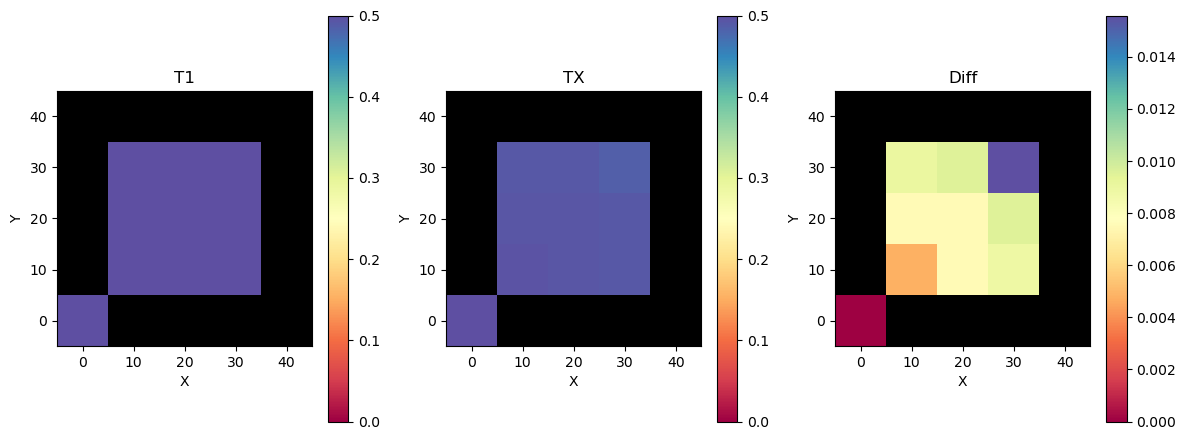

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))

plt.sca(axes[0])
imshow_grid(mg, Grid_topo[0], cmap="Spectral", vmin=0)
axes[0].set_title("T1")

plt.sca(axes[1])
imshow_grid(mg, Grid_topo[-1], cmap="Spectral", vmin=0)
axes[1].set_title("TX")

plt.sca(axes[2])
imshow_grid(mg, topoelvtn_diff, cmap="Spectral", vmin=0)
axes[2].set_title("Diff")

plt.tight_layout()
plt.show()